# Baseline Analysis

This notebook runs the first Random Forest baseline using the reusable `classical_ml.random_forest` package on the merged CMsiRNA + historic dataset. The goal is to inspect baseline behavior before tuning or changing the architecture.

In [9]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from classical_ml.random_forest import (
    RandomForestCrossValidator,
    RandomForestDataBuilder,
    RandomForestExperimentConfig,
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


ModuleNotFoundError: No module named 'classical_ml'

## Experiment Setup

In [ ]:
cmsirna_path = os.environ.get("CMSIRNA_RAW_DATA_PATH")
historic_path = os.environ.get("CMSIRNA_RAW_HISTORIC_DATA_PATH")

assert cmsirna_path, "CMSIRNA_RAW_DATA_PATH is not set"
assert historic_path, "CMSIRNA_RAW_HISTORIC_DATA_PATH is not set"

config = RandomForestExperimentConfig(
    target_column="Inhibition",
    strict_cleaning=True,
    add_mrna=True,
    use_normalized_conditions=False,
    n_splits=3,
    leak_n=30,
    random_state=42,
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    n_jobs=-1,
)

config

RandomForestExperimentConfig(target_column='Inhibition', target_len=25, strict_cleaning=True, add_mrna=True, fetch_missing_mrna=True, use_normalized_conditions=False, n_splits=3, leak_n=30, random_state=42, n_estimators=300, max_depth=None, min_samples_split=2, min_samples_leaf=1, max_features='sqrt', n_jobs=-1)

## Build Data

In [ ]:
builder = RandomForestDataBuilder(config)
prepared = builder.build_from_merged_sources(cmsirna_path, historic_path)

print("Enriched dataframe shape:", prepared.enriched_df.shape)
print("Feature matrix shape:", prepared.X.shape)
print("Target shape:", prepared.y.shape)
print("Unique genes:", len(np.unique(prepared.groups)))

loaded 3515 historic rows
merged 43153 CMsiRNA and 3515 historic rows into 46668
Running qc and data cleaning
dropped 4233 rows for in-vivo readings
dropped 565 rows for mM readings
dropped 115 rows for unknown or unwanted cell lines
dropped 47 rows for out-of-range inhibition
dropped 1749 rows for missing or unknown concentration
dropped 796 rows for concentration > 200 nM
filled 7522 rows for missing time of administration
dropped 2198 rows with a missing or >25 nt strand
dropped 6 columns: ['Modification_locations_Sense_strand', 'Modification_locations_Antisense_strand', 'Modifications_sense_strand', 'Modifications_AntiSense_strand_3_5', 'position_Antisense_strand', 'position_Sense_strand']
Mapping mRNA structural profiles
Error reading reference dataset: [Errno 2] No such file or directory: '/home/larsena8/software/fennec/src/fennec/support_files/train_data_v1.1.0_N=27742.csv'
Loaded 47 gene sequences from local cache
Loaded 0 gene sequences from reference CSV
Building gene -> mRNA

In [ ]:
prepared.enriched_df[[
    "gene_target_symbol_name",
    "Inhibition",
    "Concentration_log10_nM",
    "Time_of_administration_h",
    "edit_distance",
    "target_site_pct",
]].head()

,gene_target_symbol_name,Inhibition,Concentration_log10_nM,Time_of_administration_h,edit_distance,target_site_pct
0,CTNNB1,88.0,2.0,48.0,0.0,0.236825
1,CTNNB1,90.0,2.0,48.0,0.0,0.255693
2,CTNNB1,90.0,2.0,48.0,0.0,0.431034
3,CTNNB1,89.0,2.0,48.0,0.0,0.445999
4,CTNNB1,87.0,2.0,48.0,0.0,0.564736


## Run Baseline Cross-Validation

In [ ]:
cross_validator = RandomForestCrossValidator(config)
results = cross_validator.run_cv(prepared.X, prepared.y, prepared.groups)

fold_results = results["fold_results"]
summary = results["summary"]
predictions = results["predictions"]

fold_results

,fold,n_train,n_test,n_train_groups,n_test_groups,pearson,spearman,rmse,mae
0,1,25108,11857,54,15,0.387231,0.422562,33.176985,26.128657
1,2,25135,11830,54,16,0.339244,0.362023,30.346658,25.033787
2,3,25203,11762,54,17,0.373944,0.388909,35.485796,29.828581


In [ ]:
summary

,fold,n_train,n_test,n_train_groups,n_test_groups,pearson,spearman,rmse,mae
0,mean,25148.666667,11816.333333,54.0,16.0,0.366806,0.391165,33.003146,26.997008


## Fold-Level Behavior

Each fold is one cross-validation run with its own train/test split.

- `pearson`: linear correlation between true and predicted inhibition. Higher is better; values closer to `1` mean the model follows the true trend well.
- `spearman`: rank correlation between true and predicted inhibition. Higher is better; values closer to `1` mean the model orders stronger vs weaker siRNAs correctly.
- `rmse`: root mean squared error in inhibition units. Lower is better; large mistakes are penalized more heavily.
- `mae`: mean absolute error in inhibition units. Lower is better; this is the easiest "typical prediction error" to interpret.
- `n_train` and `n_test`: number of rows used for training and testing in that fold.
- `n_train_groups` and `n_test_groups`: number of unique genes represented in the train and test parts of that fold.

If fold metrics vary a lot, that means the baseline is sensitive to which genes ended up in each split.

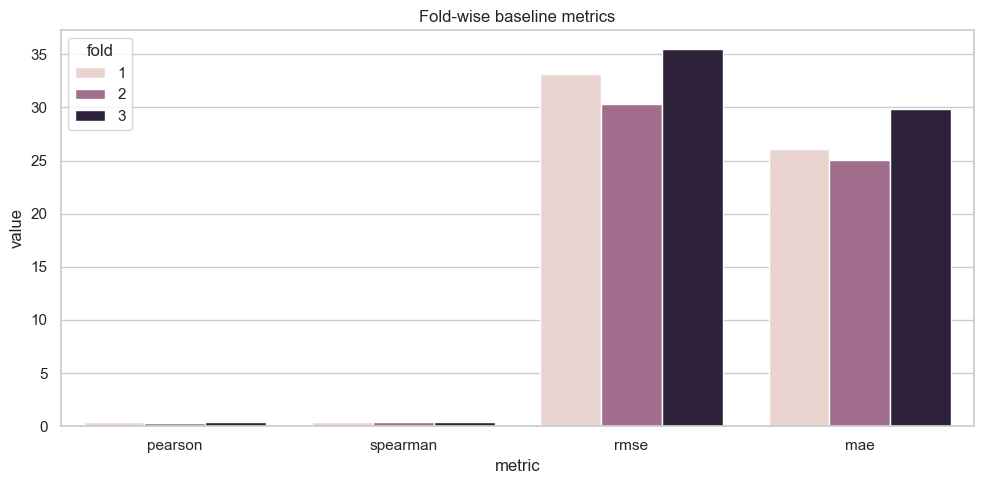

In [ ]:
metric_columns = ["pearson", "spearman", "rmse", "mae"]
melted = fold_results.melt(id_vars="fold", value_vars=metric_columns, var_name="metric", value_name="value")

plt.figure(figsize=(10, 5))
sns.barplot(data=melted, x="metric", y="value", hue="fold")
plt.title("Fold-wise baseline metrics")
plt.tight_layout()

In [ ]:
fold_results[["fold", "n_train", "n_test", "n_train_groups", "n_test_groups"]]

,fold,n_train,n_test,n_train_groups,n_test_groups
0,1,25108,11857,54,15
1,2,25135,11830,54,16
2,3,25203,11762,54,17


## Prediction Behavior

In [ ]:
predictions = predictions.copy()
predictions["residual"] = predictions["y_true"] - predictions["y_pred"]
predictions["abs_error"] = predictions["residual"].abs()
predictions.head()

In [ ]:
plt.figure(figsize=(6, 6))
sns.scatterplot(data=predictions, x="y_true", y="y_pred", hue="fold", alpha=0.7)
line_min = min(predictions["y_true"].min(), predictions["y_pred"].min())
line_max = max(predictions["y_true"].max(), predictions["y_pred"].max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle="--", color="black")
plt.title("True vs predicted inhibition")
plt.xlabel("True inhibition")
plt.ylabel("Predicted inhibition")
plt.tight_layout()

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(predictions["residual"], bins=40, ax=axes[0])
axes[0].set_title("Residual distribution")
axes[0].set_xlabel("y_true - y_pred")

sns.scatterplot(data=predictions, x="y_true", y="residual", hue="fold", alpha=0.7, ax=axes[1])
axes[1].axhline(0, linestyle="--", color="black")
axes[1].set_title("Residuals vs true inhibition")
axes[1].set_xlabel("True inhibition")

plt.tight_layout()

## Gene-Level Consequences

In [ ]:
gene_summary = predictions.groupby("group").agg(
    n_samples=("y_true", "size"),
    y_true_mean=("y_true", "mean"),
    y_pred_mean=("y_pred", "mean"),
    mae=("abs_error", "mean"),
    rmse=("residual", lambda series: np.sqrt(np.mean(np.square(series)))),
).sort_values("mae", ascending=False)
gene_summary.head(20)

In [ ]:
top_gene_count = min(15, len(gene_summary))
plot_df = gene_summary.head(top_gene_count).reset_index()

plt.figure(figsize=(12, 5))
sns.barplot(data=plot_df, x="group", y="mae")
plt.title("Genes with the largest mean absolute error")
plt.xlabel("Gene")
plt.ylabel("MAE")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

In [ ]:
plt.figure(figsize=(7, 7))
sns.scatterplot(data=gene_summary.reset_index(), x="y_true_mean", y="y_pred_mean", size="n_samples", alpha=0.8)
line_min = min(gene_summary["y_true_mean"].min(), gene_summary["y_pred_mean"].min())
line_max = max(gene_summary["y_true_mean"].max(), gene_summary["y_pred_mean"].max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle="--", color="black")
plt.title("Gene-level mean true vs predicted inhibition")
plt.xlabel("Mean true inhibition")
plt.ylabel("Mean predicted inhibition")
plt.tight_layout()

## Interpretation Notes

Use the outputs above to answer the first-step questions:

- Are Pearson and Spearman consistently positive across folds, or does performance swing a lot by fold?
- Are RMSE and MAE acceptable relative to the inhibition range in the dataset?
- Does the model systematically underpredict strong knockdown or overpredict weak knockdown?
- Which genes have the highest error, and do they have fewer samples or distinct behavior?
- If fold metrics are unstable, that suggests the baseline is sensitive to gene composition and may need tuning or feature refinement.
- If predictions collapse toward the mean, the baseline may be too conservative or not expressive enough for some target classes.

## Optional Export

In [ ]:
processed_dir = os.environ.get("CMSIRNA_PROCESSED_DIR")
if processed_dir:
    output_dir = Path(processed_dir)
    fold_results_path = output_dir / "rf_baseline_fold_results.csv"
    summary_path = output_dir / "rf_baseline_summary.csv"
    predictions_path = output_dir / "rf_baseline_predictions.csv"
    gene_summary_path = output_dir / "rf_baseline_gene_summary.csv"
    fold_results.to_csv(fold_results_path, index=False)
    summary.to_csv(summary_path, index=False)
    predictions.to_csv(predictions_path, index=False)
    gene_summary.to_csv(gene_summary_path)
    print("Saved fold results to:", fold_results_path)
    print("Saved summary to:", summary_path)
    print("Saved predictions to:", predictions_path)
    print("Saved gene summary to:", gene_summary_path)
else:
    print("CMSIRNA_PROCESSED_DIR is not set; skipping export.")

NameError: name 'os' is not defined